<a href="https://colab.research.google.com/github/cu24250216-oss/Computer-Vision-Experiments/blob/main/TANISHASINGH_60_EXPERIMENT_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LABSHEET 06**

**Implementation and Comparative Analysis of Image Segmentation Techniques using** **Python**
**and OpenCV**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

from google.colab import files
from sklearn.cluster import KMeans

Saving Screenshot 2026-03-15 222154.png to Screenshot 2026-03-15 222154.png


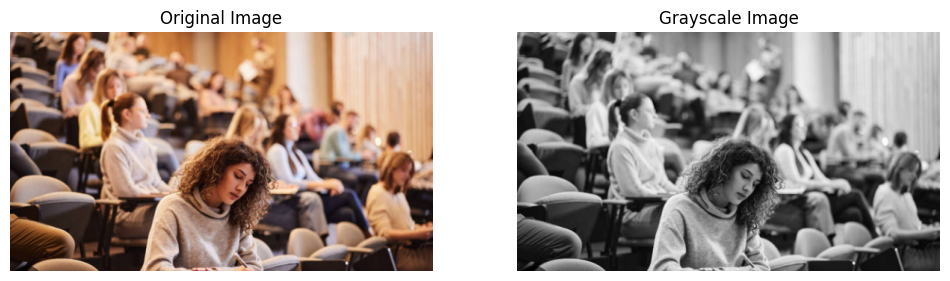

In [2]:
uploaded = files.upload()

filename = next(iter(uploaded))

image = cv2.imread(filename)

if image is None:
    raise ValueError("Image could not be loaded")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

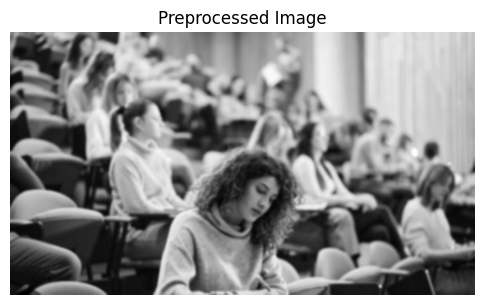

In [3]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(6, 5))
plt.imshow(blurred, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

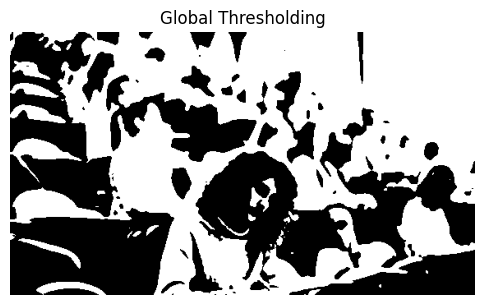

Global Thresholding Time: 0.004409 seconds


In [4]:
start = time.perf_counter()

threshold_value = 127

_, global_thresh = cv2.threshold(
    blurred,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

global_time = time.perf_counter() - start

plt.figure(figsize=(6, 5))
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")
plt.show()

print("Global Thresholding Time:", round(global_time, 6), "seconds")

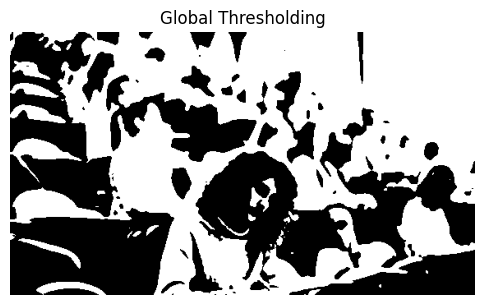

Global Thresholding Time: 0.000332 seconds


In [5]:
start = time.perf_counter()

threshold_value = 127

_, global_thresh = cv2.threshold(
    blurred,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

global_time = time.perf_counter() - start

plt.figure(figsize=(6, 5))
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")
plt.show()

print("Global Thresholding Time:", round(global_time, 6), "seconds")

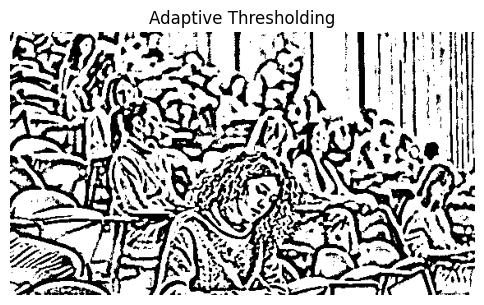

Adaptive Thresholding Time: 0.023597 seconds


In [6]:
start = time.perf_counter()

adaptive_thresh = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

adaptive_time = time.perf_counter() - start

plt.figure(figsize=(6, 5))
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")
plt.show()

print("Adaptive Thresholding Time:", round(adaptive_time, 6), "seconds")

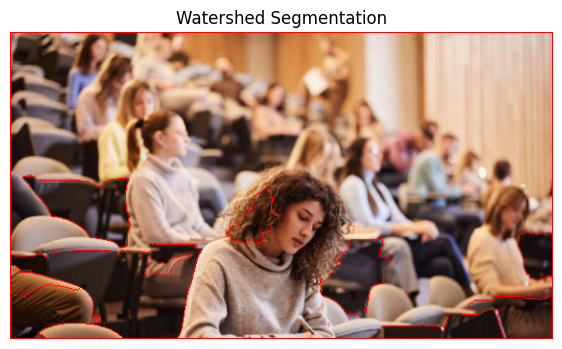

Watershed Time: 0.0119 seconds


In [9]:
start = time.perf_counter()

_, otsu_thresh = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

binary = otsu_thresh.copy()

if np.mean(binary == 255) > 0.5:
    binary = cv2.bitwise_not(binary)

kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

sure_background = cv2.dilate(
    opening,
    kernel,
    iterations=3
)

dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

_, sure_foreground = cv2.threshold(
    dist_transform,
    0.4 * dist_transform.max(),
    255,
    0
)

sure_foreground = np.uint8(sure_foreground)

unknown = cv2.subtract(
    sure_background,
    sure_foreground
)

num_labels, markers = cv2.connectedComponents(
    sure_foreground
)

markers = markers + 1

markers[unknown == 255] = 0

watershed_image = image.copy()

markers = cv2.watershed(
    watershed_image,
    markers
)

watershed_image[markers == -1] = [0, 0, 255]

watershed_time = time.perf_counter() - start

plt.figure(figsize=(7, 5))
plt.imshow(
    cv2.cvtColor(watershed_image, cv2.COLOR_BGR2RGB)
)
plt.title("Watershed Segmentation")
plt.axis("off")
plt.show()

print("Watershed Time:", round(watershed_time, 6), "seconds")

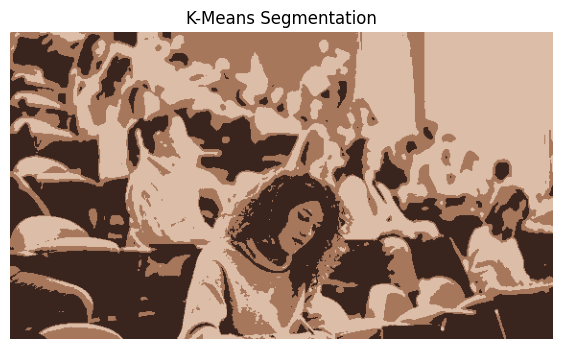

K-Means Time: 1.208005 seconds


In [10]:
start = time.perf_counter()

pixels = image_rgb.reshape((-1, 3))

pixels = np.float32(pixels)

k = 3

criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixels)

centers = np.uint8(kmeans.cluster_centers_)

segmented_pixels = centers[labels]

kmeans_image = segmented_pixels.reshape(image_rgb.shape)

kmeans_time = time.perf_counter() - start

plt.figure(figsize=(7, 5))
plt.imshow(kmeans_image)
plt.title("K-Means Segmentation")
plt.axis("off")
plt.show()

print("K-Means Time:", round(kmeans_time, 6), "seconds")

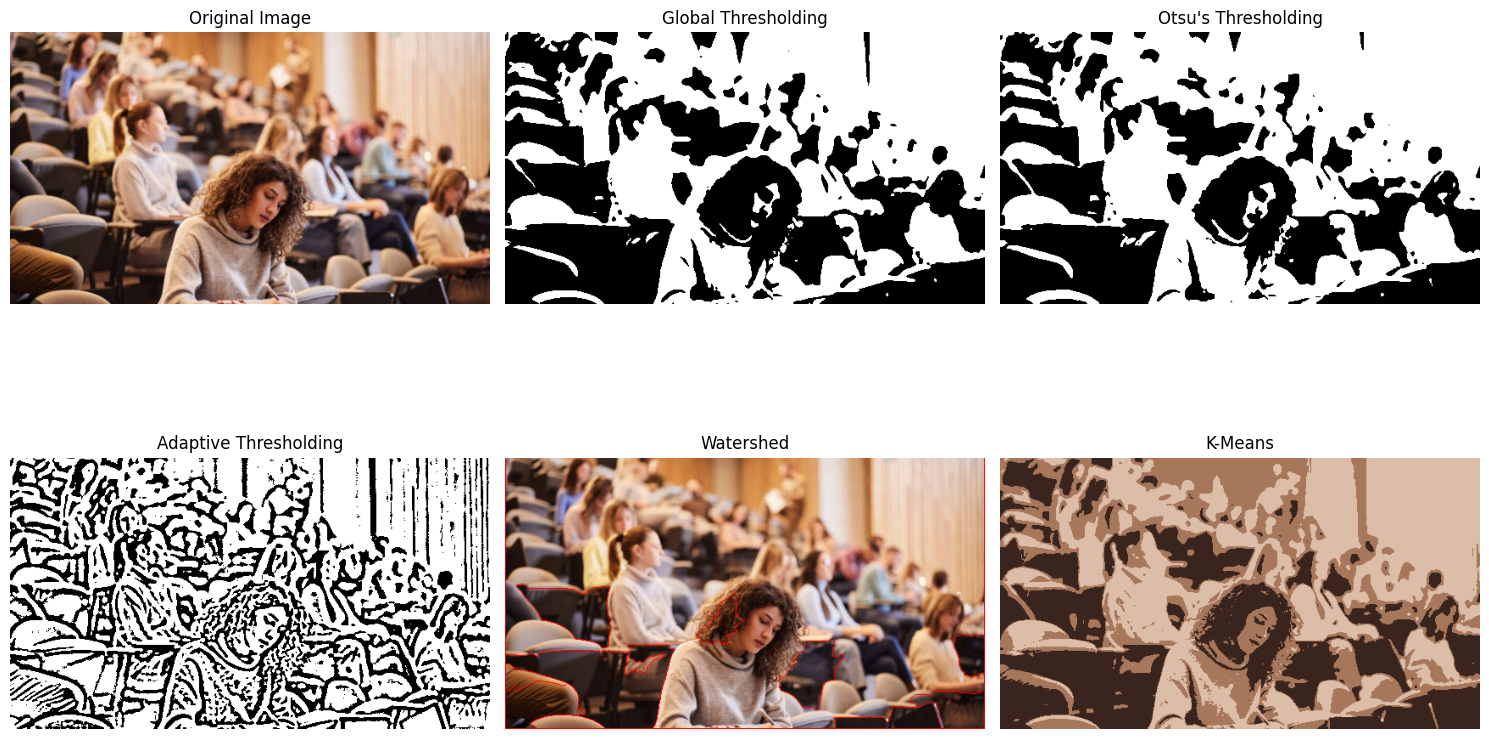

In [11]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(otsu_thresh, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(watershed_image, cv2.COLOR_BGR2RGB))
plt.title("Watershed")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(kmeans_image)
plt.title("K-Means")
plt.axis("off")

plt.tight_layout()
plt.show()

Global : 0.000306 seconds
Otsu : 0.00026 seconds
Adaptive : 0.000862 seconds
Watershed : 0.008508 seconds
K-Means : 0.530224 seconds


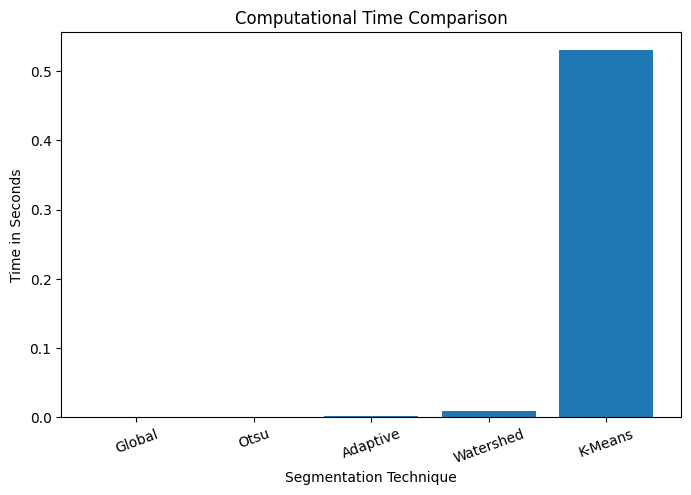

In [13]:
import time
import matplotlib.pyplot as plt

methods = [
    "Global",
    "Otsu",
    "Adaptive",
    "Watershed",
    "K-Means"
]

times = []

# Global Thresholding
start = time.perf_counter()
_, global_thresh = cv2.threshold(
    blurred, 127, 255, cv2.THRESH_BINARY
)
times.append(time.perf_counter() - start)

# Otsu's Thresholding
start = time.perf_counter()
_, otsu_thresh = cv2.threshold(
    blurred, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
times.append(time.perf_counter() - start)

# Adaptive Thresholding
start = time.perf_counter()
adaptive_thresh = cv2.adaptiveThreshold(
    blurred, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2
)
times.append(time.perf_counter() - start)

# Watershed
start = time.perf_counter()

binary = otsu_thresh.copy()

if np.mean(binary == 255) > 0.5:
    binary = cv2.bitwise_not(binary)

kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(
    binary, cv2.MORPH_OPEN, kernel, iterations=2
)

sure_background = cv2.dilate(
    opening, kernel, iterations=3
)

dist_transform = cv2.distanceTransform(
    opening, cv2.DIST_L2, 5
)

_, sure_foreground = cv2.threshold(
    dist_transform,
    0.4 * dist_transform.max(),
    255, 0
)

sure_foreground = np.uint8(sure_foreground)

unknown = cv2.subtract(
    sure_background, sure_foreground
)

num_labels, markers = cv2.connectedComponents(
    sure_foreground
)

markers = markers + 1
markers[unknown == 255] = 0

watershed_image = image.copy()
markers = cv2.watershed(watershed_image, markers)

watershed_image[markers == -1] = [0, 0, 255]

times.append(time.perf_counter() - start)

# K-Means
start = time.perf_counter()

pixels = image_rgb.reshape((-1, 3))
pixels = np.float32(pixels)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixels)

centers = np.uint8(kmeans.cluster_centers_)

segmented_pixels = centers[labels]

kmeans_image = segmented_pixels.reshape(image_rgb.shape)

times.append(time.perf_counter() - start)

# Print results
for method, elapsed in zip(methods, times):
    print(method, ":", round(elapsed, 6), "seconds")

# Plot comparison
plt.figure(figsize=(8, 5))
plt.bar(methods, times)
plt.xlabel("Segmentation Technique")
plt.ylabel("Time in Seconds")
plt.title("Computational Time Comparison")
plt.xticks(rotation=20)
plt.show()

**QUESTION **

Q1. What is image segmentation? Why is it important?

Image segmentation divides an image into meaningful regions or objects. It is important because it helps identify objects and separate them from the background.

Q2. Differentiate between image segmentation and classification.

Segmentation



Classification




Divides an image into regions.



Assigns a label to an image.




Provides pixel-level information.



Provides image-level information.




Example: Separating a tumor.



Example: Classifying an image as healthy or diseased.

Q3. Explain Global, Otsu's, and Adaptive Thresholding.

Global: Uses one fixed threshold for the entire image.

Otsu's: Automatically selects the best threshold using the image histogram.

Adaptive: Uses different thresholds for different local regions

Q4. What is the Watershed Algorithm? Why is it useful?

Watershed is a segmentation technique that divides an image into regions using boundaries. It is useful for separating overlapping objects such as touching coins and cells.

Q5. How is K-Means used in image segmentation?

K-Means groups pixels with similar colors or intensities into clusters. Each cluster represents a segment of the image. The value of K determines the number of clusters.

Q6. Compare threshold-based and clustering-based segmentation.

Threshold-Based



Clustering-Based




Uses threshold values.



Groups similar pixels.




Simple and fast.



More computationally expensive.




Suitable for simple images.



Suitable for multiple color regions.




Example: Otsu's method.



Example: K-Means.

Q7. What challenges occur with overlapping objects?

Objects have unclear boundaries.

Objects may have similar colors.

Shadows and noise affect segmentation.

Objects may touch each other.

Over-segmentation may occur.

Solution: Watershed and morphological operations can help separate overlapping objects.

Q8. Mention five applications of image segmentation.

Medical image analysis.

Autonomous vehicles.

Satellite image processing.

Agriculture.

Industrial inspection.

Q9. How does segmentation improve object detection?

Image segmentation removes background noise and identifies exact object boundaries. It improves object localization, shape measurement, recognition, and separation of overlapping objects.

Q10. Compare traditional segmentation with U-Net and Mask R-CNN.

Traditional Methods



Deep Learning Methods




Use manually designed algorithms.



Learn from training data.




Examples: Thresholding, K-Means.



Examples: U-Net, Mask R-CNN.




Simple and fast for basic images.



Better for complex images when trained well.




Require less training data.



Usually require annotated datasets.

U-Net performs pixel-level semantic segmentation, while Mask R-CNN detects objects and creates a separate mask for each object.